In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv("C:/Users/hp/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
df.shape

(7043, 21)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [55]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [56]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [57]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [58]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* Here we see that the TotalCharges has 11 missing values. Let's check this data.

In [59]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* It can also be noted that the Tenure column is 0 for these entries even though the MonthlyCharges column is not empty.
Let's see if there are any other 0 values in the tenure column

In [60]:
df[df['tenure']== 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

* Let's remove those 11 missing values in tenure and MonthlyCharges columns.

In [61]:
df.dropna(inplace=True)

In [62]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [63]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: "No",1: "Yes"})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


* We don't need customerID column so droping it.

In [65]:
df.drop(labels='customerID',axis=1,inplace=True)

In [66]:
categoriacl_cols = df.select_dtypes(include=['object','category']).columns
categoriacl_cols

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [67]:
for i in categoriacl_cols:
    print(df[i].value_counts())
    print(' ')

gender
Male      3549
Female    3483
Name: count, dtype: int64
 
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64
 
Partner
No     3639
Yes    3393
Name: count, dtype: int64
 
Dependents
No     4933
Yes    2099
Name: count, dtype: int64
 
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
 
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64
 
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
 
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64
 
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64
 
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64
 
TechSupport
No                     3472
Yes                    2040
No internet

# Data Visualization.

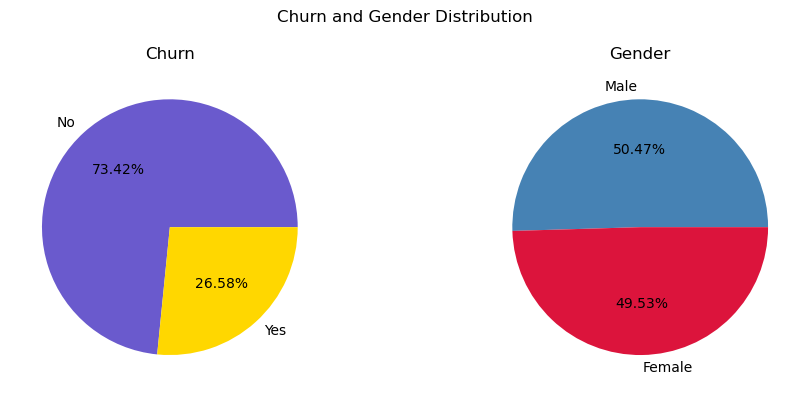

In [68]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax1.pie(df['Churn'].value_counts(),
             labels = df['Churn'].value_counts().index,
             colors = ['slateblue','gold'],
             autopct='%1.2f%%')
ax1.set_title('Churn')

ax2.pie(df['gender'].value_counts(),
             labels = ['Male','Female'],
             colors = ['steelblue','crimson'],  
             autopct= '%1.2f%%')
ax2.set_title('Gender')

plt.suptitle('Churn and Gender Distribution')
plt.tight_layout()
plt.show()

* 26.5% of the Customers Churned.
* Male and Female Customers are almost equal.

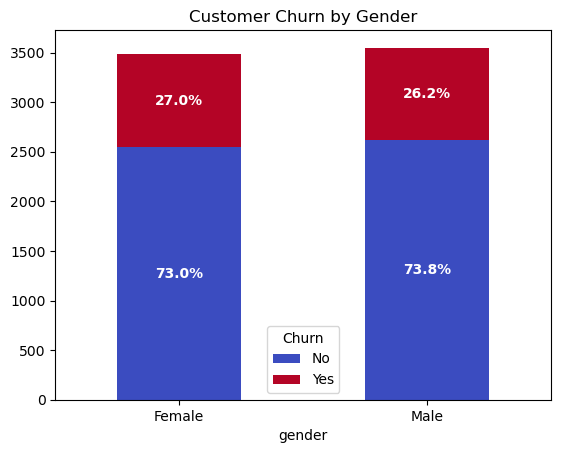

In [69]:
df_stack = df[['gender','Churn']].groupby(['gender','Churn']).size()
df_stack = df_stack.unstack()

ax = df_stack.plot(kind='bar',stacked=True,colormap='coolwarm')
plt.xticks(rotation=0)
plt.title('Customer Churn by Gender')
totals = df_stack.sum(axis=1).values

for i in ax.containers:
    perc = (i.datavalues / totals) * 100

    custom_lables = [f'{p:.1f}%' for p in perc]
    
    ax.bar_label(i, labels=custom_lables, label_type='center',color='white',weight='bold')
plt.show()

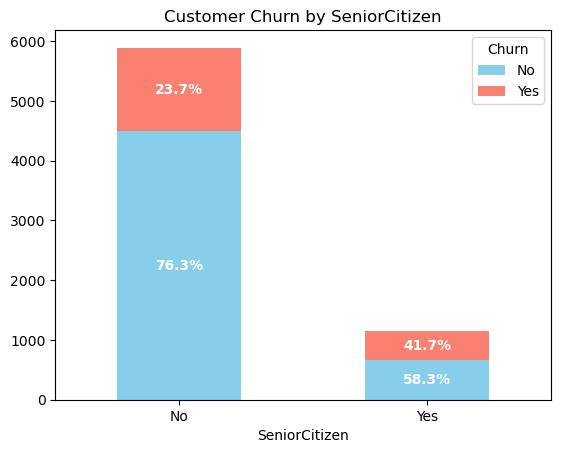

In [70]:
df_stack = df[['SeniorCitizen','Churn']].groupby(['SeniorCitizen','Churn']).size()
df_stack = df_stack.unstack()

ax = df_stack.plot(kind='bar',stacked=True,color=['skyblue','salmon'])
plt.xticks(rotation=0)
plt.title('Customer Churn by SeniorCitizen')
totals = df_stack.sum(axis=1).values

for i in ax.containers:
    perc = (i.datavalues / totals) * 100

    custom_lables = [f'{p:.1f}%' for p in perc]
    
    ax.bar_label(i, labels=custom_lables, label_type='center',color='white',weight='bold')
plt.show()

* Senior Citizens have almost double the churn rate(41.7%) than younger customers.

In [71]:
fig = px.histogram(df,x='Contract',color='Churn',barmode='group',text_auto=True,
                      title='Customer Churn by Contract Type')

fig.update_layout(width=700, height=500,
                  xaxis_title="Contract Duration",
                  yaxis_title="Number of Customers",
                  legend_title="Churn Status",
                  bargap=0.15,         
                  font=dict(family="Arial, sans-serif", size=13)
                  )
fig.show()

* 42% of customers with the Month-to-month contract have churned.
* 11% of the customers with one year contract and 3% with two year contract have churned.

In [72]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure()

fig.add_trace(go.Pie(
    values=values,
    labels=labels,
    hole=0.3,
))

fig.update_layout(
    title_text="<b>Payment Method Distribution</b>",
    width=700,height=500,
    margin=dict(t=50,b=50,l=50,r=50))

fig.show()

In [73]:
fig = px.histogram(data_frame=df,
                   x='Churn',
                   color='PaymentMethod',
                   text_auto=True,
                   title='Customer Chrun by Payment Method')

fig.update_layout(width=700, height=600,
                  xaxis_title="Churn",
                  yaxis_title="Number of Customers",
                  legend_title="Payment Method",
                  bargap=0.15,         
                  font=dict(family="Arial, sans-serif", size=13)
                  )
fig.show()

* Major customers who moved out were having Electronic Check as Payment Method.
* Customers who opted for Credit-Card automatic transfer or Bank Automatic Transfer and Mailed Check as Payment Method were less likely to move out.

In [74]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [75]:
fig =px.histogram(data_frame=df,
                  x='InternetService',
                  color='Churn',
                  text_auto=True,
                  barmode='group',
                  title='Churn By Internet Service')

fig.update_layout(width=700, height=500,
                  xaxis_title="Inernet Service Type",
                  yaxis_title="Number of Customers",
                  legend_title="Churn Status",
                  bargap=0.15,         
                  font=dict(family="Arial, sans-serif", size=13)
                  )
fig.show()

* Customers with Fiber optic Inernet Service are more likely to churn.

In [76]:
fig = px.histogram(df, 
                   x="gender", 
                   color="InternetService", 
                   facet_col="Churn", 
                   barmode="group",
                   title="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.update_layout(width=900, height=500,
                  xaxis_title="gender",
                  yaxis_title="Number of Customers",
                  legend_title="Payment Method",
                  bargap=0.15,         
                  font=dict(family="Arial, sans-serif", size=13)
                  )
fig.show()

* A lot of customers choose the Fiber optic service and it's also evident that the customers who use Fiber optic have high churn rate, this might suggest a dissatisfaction with this type of internet service.

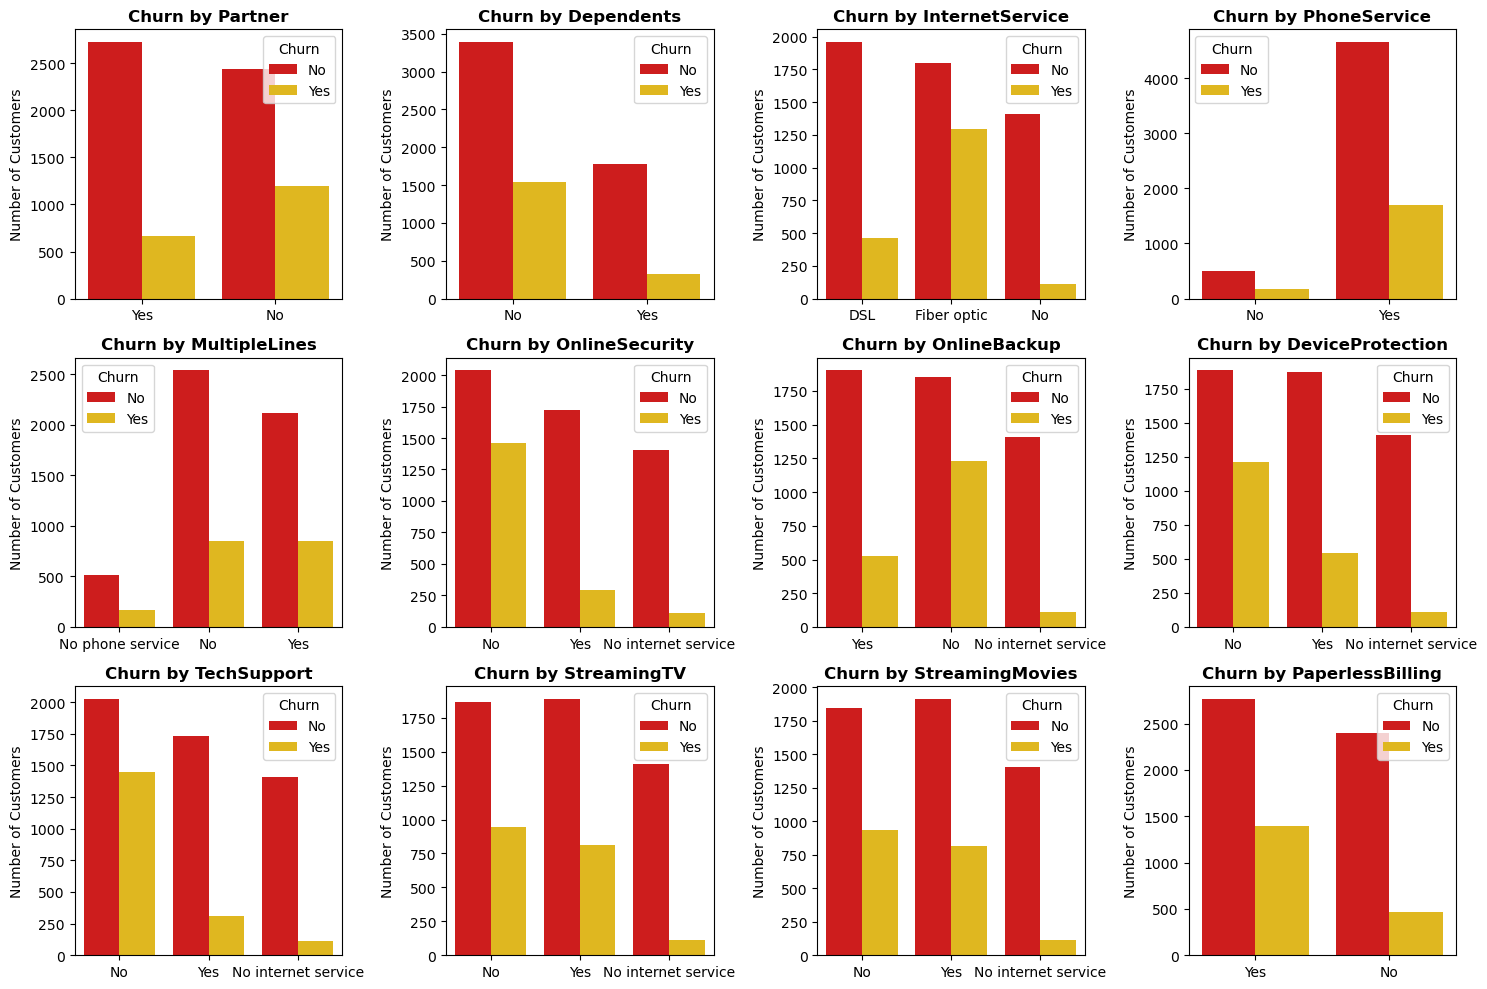

In [77]:
services = ['Partner', 'Dependents','InternetService','PhoneService', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup','DeviceProtection', 'TechSupport','StreamingTV','StreamingMovies', 'PaperlessBilling']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))

axes = axes.flatten()

for i, service in enumerate(services):
   
    sns.countplot(data=df, x=service, hue='Churn', ax=axes[i], palette='hot')
    
    axes[i].set_title(f'Churn by {service}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Number of Customers')

#for j in range(len(services), len(axes)):
    #fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

* Customers without Online Security and Tech Support have higher churn rate.
* Customers without Device Protection and Online Backup are more likely to churn.
* Customers without Partner or Dependent have comparatively higher churn rate.

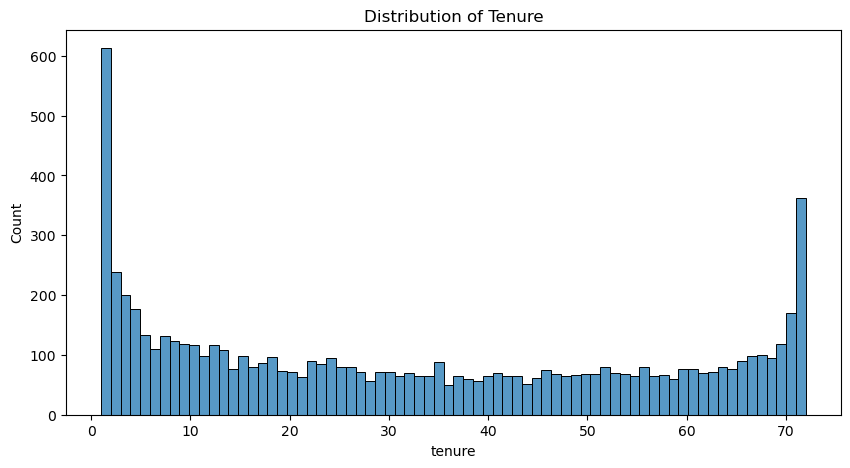

In [78]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='tenure',bins=72)
plt.title('Distribution of Tenure')
plt.show()

As we can see a lot of customers have only one month tenure and also there are many customers who have total 72 months of tenure.

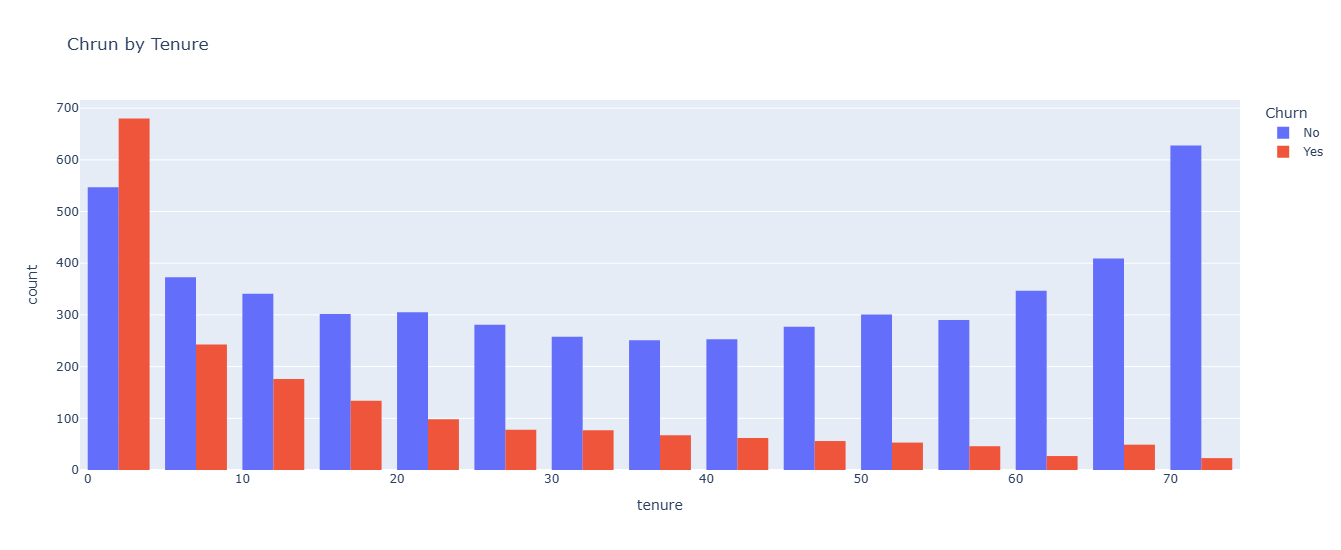

In [114]:
fig = px.histogram(data_frame=df,x='tenure',color='Churn',nbins=20,barmode='group',
                  title='Chrun by Tenure')
fig.update_layout(width=1000,height=550)
fig.show()

* Customers Churn is very high within 1-4 month after joining the services.

In [79]:
fig = px.box(df,x='Churn',y='tenure')

fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)

fig.update_xaxes(title_text='Churn', row=1, col=1)

fig.update_layout(autosize=True, width=750, height=550,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

* Median tenure for churn is 10 months Customers with less tenure than one year are more likely to churn.

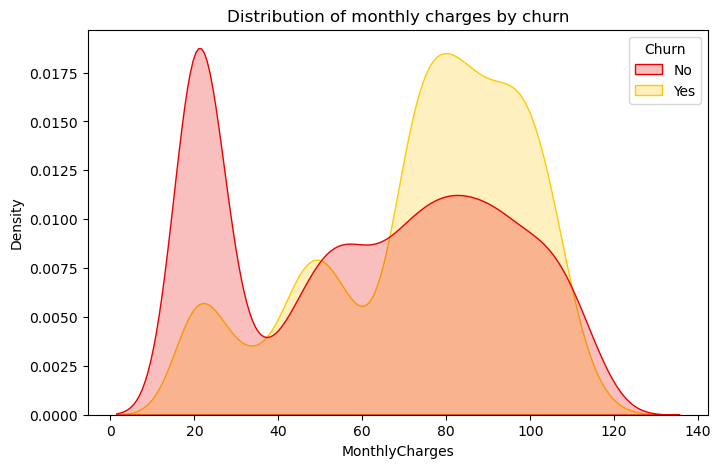

In [97]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='MonthlyCharges',hue='Churn',fill=True,common_norm=False,palette='hot')
plt.title('Distribution of monthly charges by churn')
plt.show()

* Customers With higher monthly charges are more likely to churn.

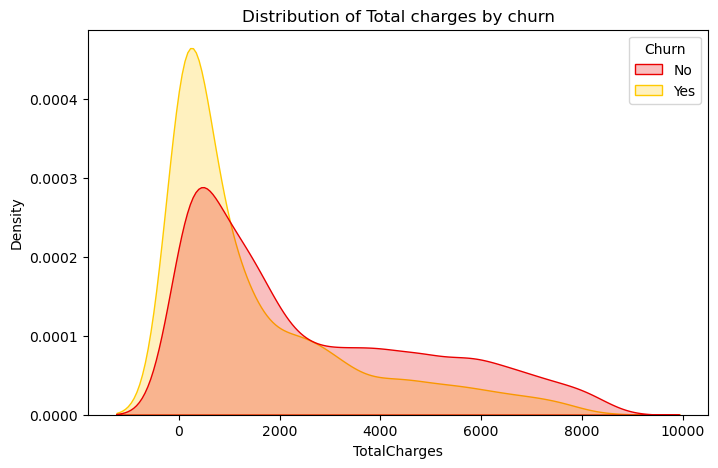

In [96]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='TotalCharges',hue='Churn',fill=True,common_norm=False,palette='hot')
plt.title('Distribution of Total charges by churn')
plt.show()

* The peak at the low charges reaffirms that many customers churn early so the total charges are low.